# 📊 Sales Analysis - AAL (Australia Apparel Ltd)

Fourth Quarter Sales Analysis (2020)

---

## Project Statement
AAL is analyzing its Q4 sales data across Australian states to:
1. Identify high revenue states
2. Improve low-performing regions
3. Enable data-driven expansion decisions


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")



In [ ]:
# Load dataset into a pandas dataframe
df = pd.read_csv('./Data/AusApparalSales4thQrt2020.csv')
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [35]:
# Clean the data. Remove the extra spaces in the columns
df['Time'] = df['Time'].str.strip()
df['State'] = df['State'].str.strip()
df['Group'] = df['Group'].str.strip()

In [29]:
df['Group'] = str(df['Group'])

In [36]:
df.iloc[1,1]

'Morning'

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7560 entries, 2020-10-01 to 2020-12-30
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Time              7559 non-null   object 
 1   State             7560 non-null   object 
 2   Group             7560 non-null   object 
 3   Unit              7560 non-null   int64  
 4   Sales             7560 non-null   int64  
 5   Sales_Normalized  7560 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 413.4+ KB


## 1. Data Wrangling

In [5]:
# Check missing values
df.isna().sum()

Date     0
Time     1
State    0
Group    0
Unit     0
Sales    0
dtype: int64

### Handling Missing Data
- Drop rows if minimal missing values
- Fill using mean/median if necessary


In [6]:
# Example: fill missing numeric values
df.fillna(df.mean(numeric_only=True), inplace=True)

### Normalization

In [7]:
# Normalize Sales column
df['Sales_Normalized'] = (df['Sales'] - df['Sales'].min()) / (df['Sales'].max() - df['Sales'].min())
df.head()

,Date,Time,State,Group,Unit,Sales,Sales_Normalized
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873


### GroupBy Insight

In [8]:
# Group by State
state_group = df.groupby('State')['Sales'].sum()
state_group

State
NSW     74970000
NT      22580000
QLD     33417500
SA      58857500
TAS     22760000
VIC    105565000
WA      22152500
Name: Sales, dtype: int64

## 2. Data Analysis

In [10]:
# Descriptive statistics
df[['Sales','Unit']].describe()

,Sales,Unit
count,7560.000000,7560.000000
mean,45013.558201,18.005423
std,32253.506944,12.901403
min,5000.000000,2.000000
25%,20000.000000,8.000000
50%,35000.000000,14.000000
75%,65000.000000,26.000000
max,162500.000000,65.000000


In [11]:
# Mean, Median, Mode, Std
stats = {
    'Mean': df['Sales'].mean(),
    'Median': df['Sales'].median(),
    'Mode': df['Sales'].mode()[0],
    'Std': df['Sales'].std()
}
stats

{'Mean': np.float64(45013.5582010582),
 'Median': np.float64(35000.0),
 'Mode': np.int64(22500),
 'Std': np.float64(32253.506943966073)}

In [12]:
# Highest and lowest sales states
highest_state = state_group.idxmax()
lowest_state = state_group.idxmin()

highest_state, lowest_state

(' VIC', ' WA')

### Time-based Analysis

In [13]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

weekly = df.resample('W')['Sales'].sum()
monthly = df.resample('M')['Sales'].sum()
quarterly = df.resample('Q')['Sales'].sum()

weekly.head(), monthly.head(), quarterly.head()

C:\Users\santu\AppData\Local\Temp\ipykernel_19792\3236321248.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M')['Sales'].sum()
C:\Users\santu\AppData\Local\Temp\ipykernel_19792\3236321248.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df.resample('Q')['Sales'].sum()


(Date
 2020-10-04    15045000
 2020-10-11    27002500
 2020-10-18    26640000
 2020-10-25    26815000
 2020-11-01    21807500
 Freq: W-SUN, Name: Sales, dtype: int64,
 Date
 2020-10-31    114290000
 2020-11-30     90682500
 2020-12-31    135330000
 Freq: ME, Name: Sales, dtype: int64,
 Date
 2020-12-31    340302500
 Freq: QE-DEC, Name: Sales, dtype: int64)

## 3. Data Visualization

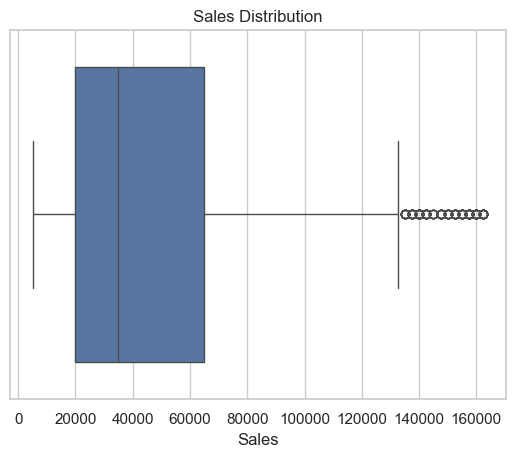

In [14]:
# Box plot
plt.figure()
sns.boxplot(x=df['Sales'])
plt.title("Sales Distribution")
plt.show()

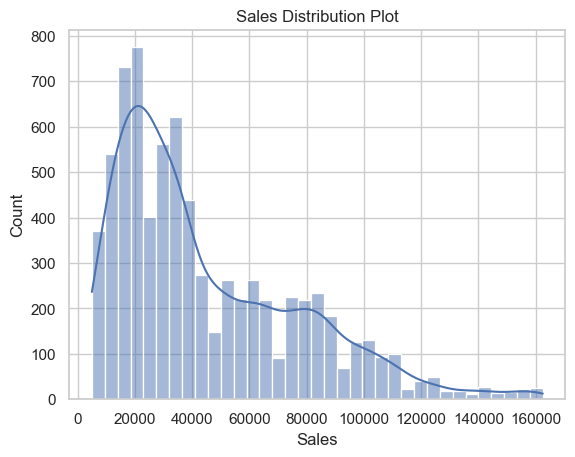

In [15]:
# Distribution plot
plt.figure()
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution Plot")
plt.show()

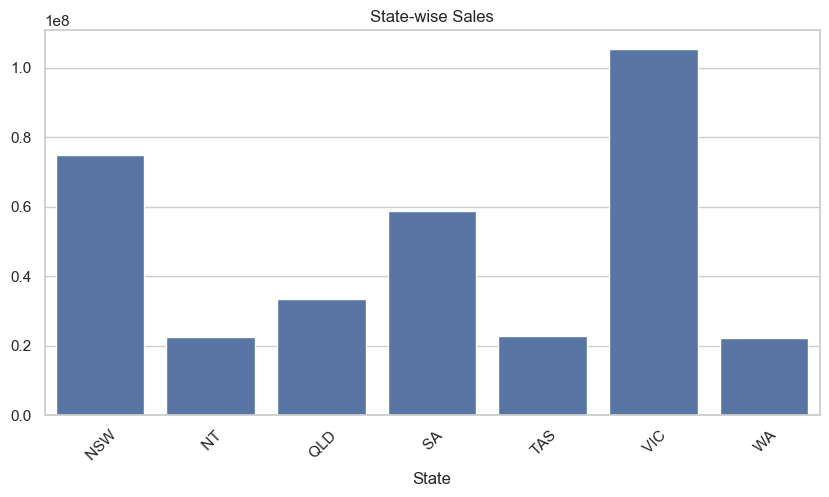

In [16]:
# State-wise sales
plt.figure(figsize=(10,5))
sns.barplot(x=state_group.index, y=state_group.values)
plt.xticks(rotation=45)
plt.title("State-wise Sales")
plt.show()

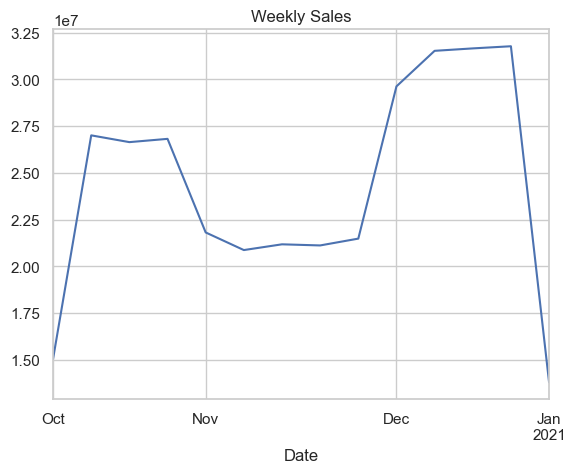

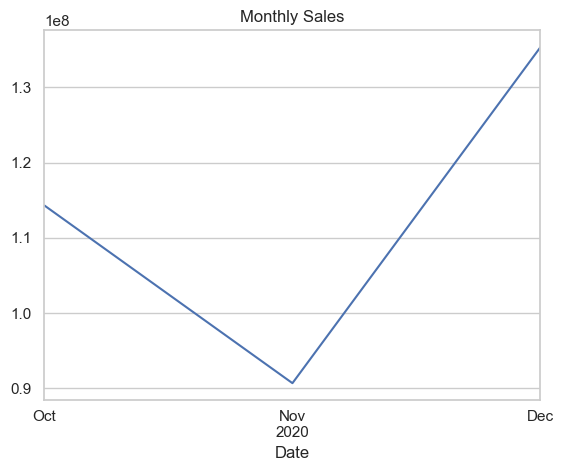

c:\PRANAB\CODE\Python Training\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


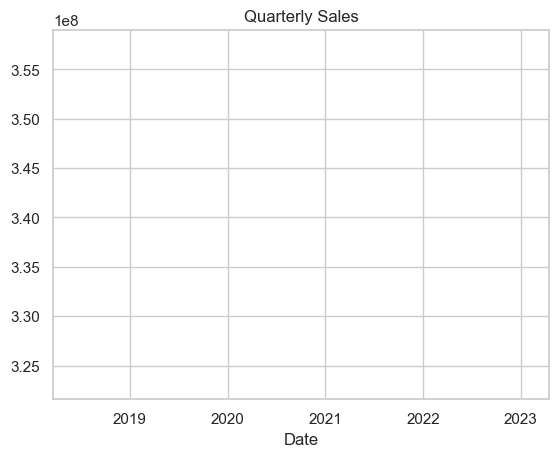

In [17]:
# Time series plots
weekly.plot(title='Weekly Sales')
plt.show()

monthly.plot(title='Monthly Sales')
plt.show()

quarterly.plot(title='Quarterly Sales')
plt.show()

## 4. Recommendations
- Focus marketing in low-performing states
- Use peak time insights for promotions
- Expand high-performing regions
- Seaborn used for statistical clarity and simplicity
